In [1]:
%load_ext autoreload
%autoreload 2

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
# from quantem.diffractive_imaging.pftm import PFTM, PFTM_DIP
from quantem.core.visualization import show_2d

from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.visualization.visualization import show_2d
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.detector_models import DetectorPixelated
from quantem.diffractive_imaging.object_models import ObjectDIP, ObjectPixelated
from quantem.diffractive_imaging.probe_models import ProbePixelated
from quantem.diffractive_imaging.ptychography import Ptychography
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
from quantem.diffractive_imaging.object_models import ObjectMultiplexed
import torch


config.set_device(0)
print(config.get("device"))


import pickle
from matplotlib import pyplot as plt
import numpy as np
import abtem
from abtem.waves import Probe
from stem_utils import (
    ptycho_wrapper,
    generate_datacube
)
from abtem.waves import Probe

ACC_VOLTAGE     = 60e3   # eV
PROBE_SEMIANGLE = 20     # mrad
PROBE_DEFOCUS   = 30    # Å
SCAN_STEP_SIZE  = 0.5    # Å

with open('DIP_phases_wide_stich.pkl', 'rb') as f:
    data = pickle.load(f)

x = data['x']
y = data['y']

cuda:0


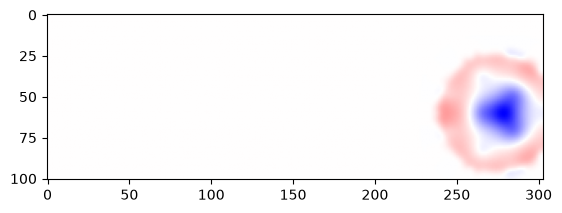

In [28]:
diff_img = data['stitched'][3] - data['stitched'][0]
color_extent = np.max(np.abs(diff_img))
plt.imshow(diff_img, cmap='bwr', vmin=-color_extent, vmax=color_extent)

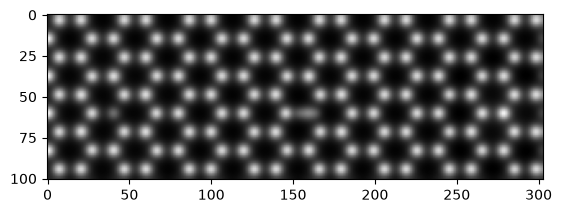

In [29]:
plt.imshow(data['stitched'][0], cmap='gray')

In [3]:
def generate_merged_scan(im1, im2, x=x, y=y, dose=None, dp_trim=65, normalize=True):
    meas1 = generate_datacube(
        im1, 
        x, y,
        acc_voltage=ACC_VOLTAGE, 
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, 
        scan_step_size=SCAN_STEP_SIZE
    )
    meas2 = generate_datacube(
        im2, 
        x, y,
        acc_voltage=ACC_VOLTAGE, 
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, 
        scan_step_size=SCAN_STEP_SIZE
    )

    if dose is not None:
        meas1 = meas1.poisson_noise(dose)
        meas2 = meas2.poisson_noise(dose)

    dcube1 = np.array(meas1.array)[:,:,dp_trim:-dp_trim,dp_trim:-dp_trim]
    dcube2 = np.array(meas2.array)[:,:,dp_trim:-dp_trim,dp_trim:-dp_trim]

    # create the cheker-board mask
    scan_mask = np.zeros(dcube2.shape[:2], dtype=np.uint8)
    x_i = np.arange(scan_mask.shape[0])
    y_i = np.arange(scan_mask.shape[1])
    for i in x_i:
        for j in y_i:
            if (i + j) % 2 == 0:
                scan_mask[i, j] = 1
    merged_scan = np.array(dcube1)
    merged_scan[scan_mask==1,:,:] = np.array(dcube2)[scan_mask==1,:,:]

    if normalize:
        for i in range(merged_scan.shape[0]):
            for j in range(merged_scan.shape[1]):
                merged_scan[i,j,:,:] = merged_scan[i,j,:,:] / merged_scan[i,j,:,:].sum()
    return merged_scan, scan_mask

In [4]:
def mixed_obj_ptycho_wrapper(
    dcube,
    scan_mask,
    # opt_params
    obj_lr=1e-3,
    probe_lr=1e-5,
    tv_weight=1,
    tv_channel_diff=0,
    channel_diff_sparcity=10,
    num_iters=25,
    batch_size=256,
    obj_padding=16,
    plot=True,
    return_extra=True,
):
    opt_params = { # except type, all args are passed to the optimizer (of type type)
        "object": {
            "type": "adam", 
            "lr": obj_lr
        },
        "probe": {
            "type": "adam", 
            "lr": probe_lr, 
        },
    }
    scheduler_params = {
        "object": { ## scheduler kwargs are passed to the scheduler (of type type)
            "type": "plateau", ## i like plateau for many cases
            # "type": "exp",
            # "factor": 9e-2,
        },
        "probe": {
            "type": "plateau",
        },
    }
    constraints = {
        "object": {
            "tv_weight_xy": tv_weight, ## these are mostly the defaults 
            "tv_channel_diff": tv_channel_diff,
            "channel_diff_sparcity": channel_diff_sparcity,
            "fix_potential_baseline": False,
            "identical_slices": True, ## default for this is False 
            "apply_fov_mask": False,
        },
        "probe": {
            "center_probe": False,
            "orthogonalize_probe": True,
        },
        "dataset":{
            "descan_tv_weight": 0,
            "descan_shifts_constant": False, 
        }
    }

    dset = Dataset4dstem.from_array(
        dcube,
        name='merged_scan',
        sampling=(SCAN_STEP_SIZE, SCAN_STEP_SIZE, 1, 1),
        units=("A", "A", "pixels", "pixels")
    )
    probe_qy0, probe_qx0, probe_R = fit_probe_circle(dset.dp_mean.array, show=False)
    dset.sampling[2] = PROBE_SEMIANGLE / probe_R
    dset.sampling[3] = PROBE_SEMIANGLE / probe_R
    dset.units[2:] = ["mrad", "mrad"]
    probe_R = PROBE_SEMIANGLE / dset.sampling[2]

    pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
    pdset.preprocess(
        com_fit_function="constant",
        plot_rotation=False,
        plot_com=False,
        probe_energy=ACC_VOLTAGE,
        force_com_rotation=0, 
        force_com_transpose=False,
    )    

    probe_params = {
        "energy" : ACC_VOLTAGE,
        "defocus" : PROBE_DEFOCUS,
        "semiangle_cutoff" : PROBE_SEMIANGLE, 
    }
    detector_model = DetectorPixelated() 

    # Set up ptychography model for excited state
    probe_model = ProbePixelated.from_params(
        num_probes=1,
        probe_params=probe_params,
    )
    obj_model = ObjectMultiplexed.from_uniform(
        num_slices=1, 
        slice_thicknesses=1,
        obj_type='pure_phase',
        num_channels=2,
        patches_mask=torch.tensor(scan_mask)
    )
    ptycho = Ptychography.from_models(
        dset=pdset,
        obj_model=obj_model,
        probe_model=probe_model,
        detector_model=detector_model,
        device='cuda',
    )

    ptycho.preprocess( 
        obj_padding_px=(obj_padding, obj_padding),
        batch_size=batch_size,
    )
    ptycho.reconstruct(
        num_iters=num_iters,
        reset=True,
        autograd=True, 
        device='cuda',
        constraints=constraints, 
        optimizer_params=opt_params,
        scheduler_params=scheduler_params,
        batch_size=batch_size,
        multichannel_mode=True,
    ) # .visualize()

    recon_off = np.angle(
        ptycho.obj_model.obj[
            0,0,obj_padding:-obj_padding,obj_padding:-obj_padding
            ].cpu().detach().cpu().numpy())
    recon_on = np.angle(
        ptycho.obj_model.obj[
            1,0,obj_padding:-obj_padding,obj_padding:-obj_padding
            ].cpu().detach().cpu().numpy())

    if not plot:
        return recon_off, recon_on
    
    ptycho.plot_losses()
    
    diff = recon_on - recon_off
    diff_extent = np.max(np.abs(diff))
    plt.figure()
    plt.subplot(2,1,1)
    plt.imshow(recon_off, cmap='gray')
    plt.colorbar()
    plt.subplot(2,1,2)
    plt.imshow(diff, cmap='seismic', vmin=-diff_extent, vmax=diff_extent)
    plt.colorbar()
    plt.show()

    if return_extra:
        return recon_off, recon_on, ptycho
    return recon_off, recon_on

tasks:  13%|#3        | 3/23 [00:00<00:03,  5.39it/s]

tasks:  13%|#3        | 3/23 [00:00<00:03,  5.30it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

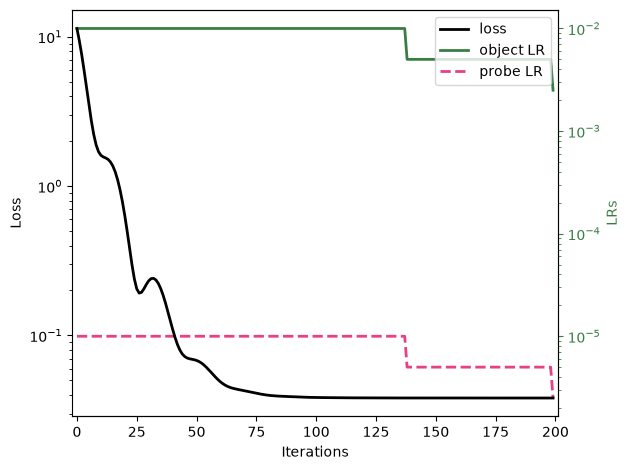

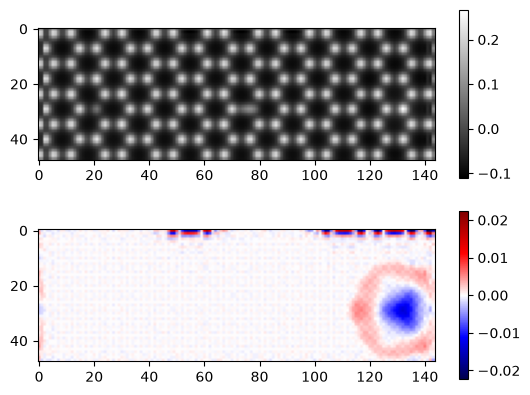

In [59]:
# unconstaint, infinite dose 
scan, scan_mask = generate_merged_scan(
    data['stitched'][0], 
    data['stitched'][3], 
    dose=None,
    dp_trim=30,
)
recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
    dcube=scan,
    scan_mask=scan_mask,
    num_iters=200,
    tv_channel_diff=0.0,
    tv_weight=0.0,
    channel_diff_sparcity=0.0,
    obj_lr=1e-2,
    return_extra=True,
    batch_size=2**12,
    obj_padding=64
)


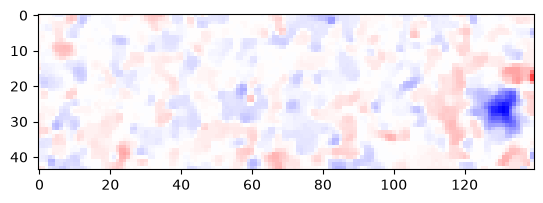

In [38]:
plt.imshow(    
    np.angle(ptycho.obj[1,0,66:-66,66:-66])
    - np.angle(ptycho.obj[0,0,66:-66,66:-66])
    ,
    cmap='seismic', vmin=-0.02, vmax=0.02
)

tasks:  13%|#3        | 3/23 [00:00<00:04,  4.72it/s]

tasks:  13%|#3        | 3/23 [00:00<00:03,  5.05it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

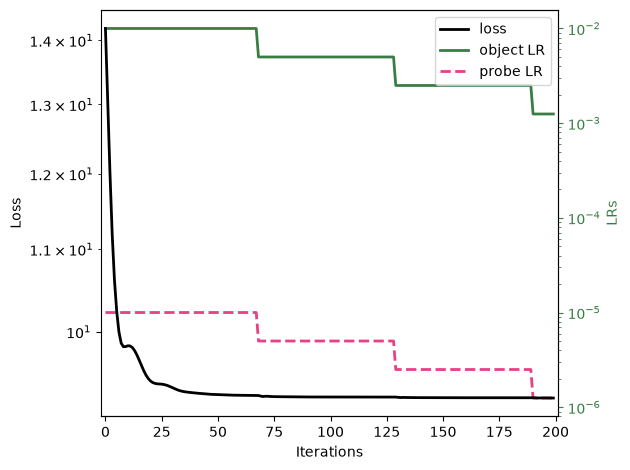

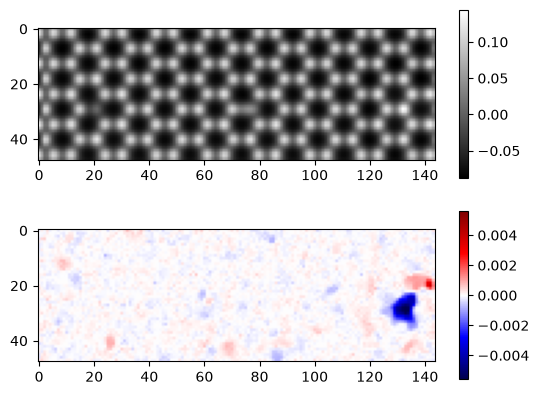

In [ ]:
scan, scan_mask = generate_merged_scan(
    data['stitched'][0], 
    data['stitched'][3], 
    dose=1e6,
    dp_trim=30,
)



Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

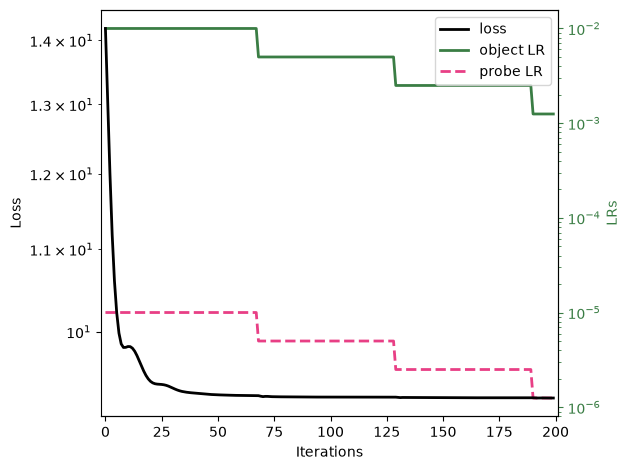

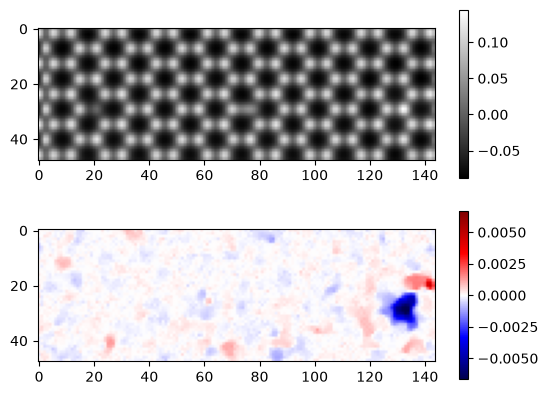

In [41]:
recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
    dcube=scan,
    scan_mask=scan_mask,
    num_iters=200,
    tv_channel_diff=10.0,
    tv_weight=0.0,
    channel_diff_sparcity=3.0,
    obj_lr=1e-2,
    return_extra=True,
    batch_size=2**12,
    obj_padding=64
)

In [50]:
scan, scan_mask = generate_merged_scan(
    data['stitched'][0], 
    data['stitched'][3], 
    dose=1e5,
    dp_trim=30,
)

tasks:  13%|#3        | 3/23 [00:00<00:03,  5.34it/s]

tasks:  13%|#3        | 3/23 [00:00<00:03,  5.26it/s]

tv_channel_diff=0, channel_diff_sparcity=0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

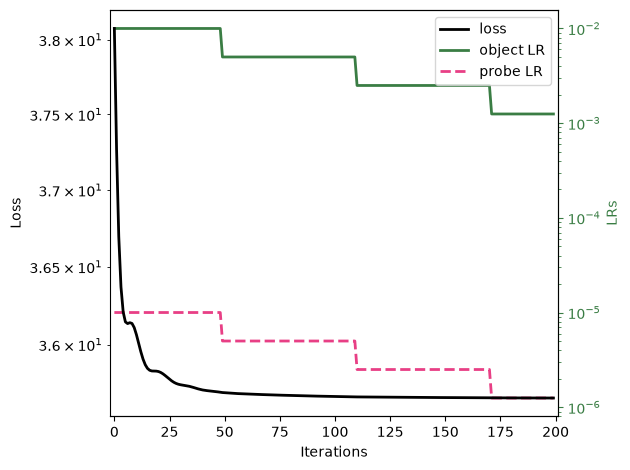

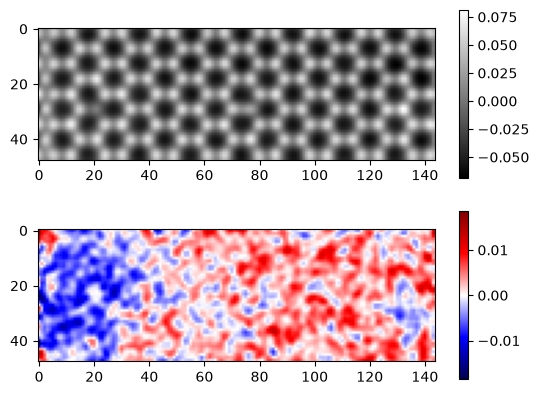

tv_channel_diff=0, channel_diff_sparcity=1
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

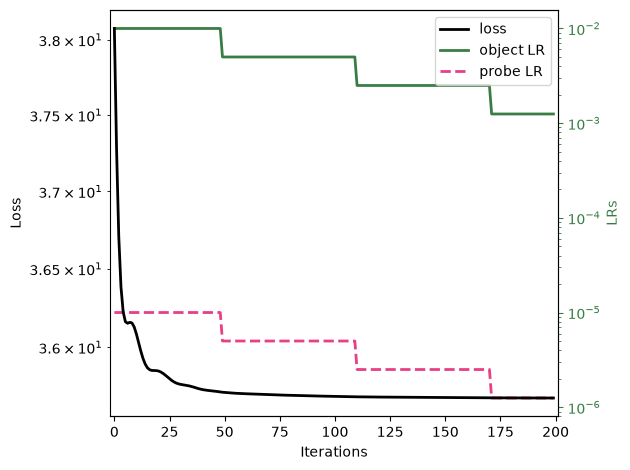

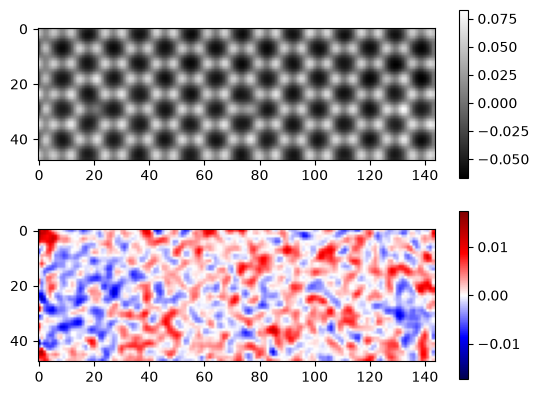

tv_channel_diff=0, channel_diff_sparcity=3
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

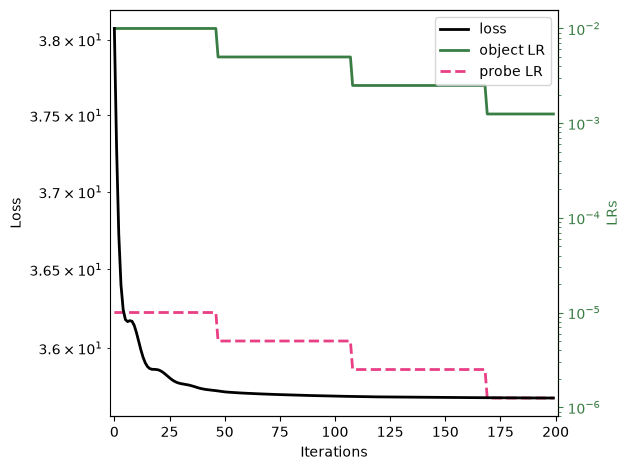

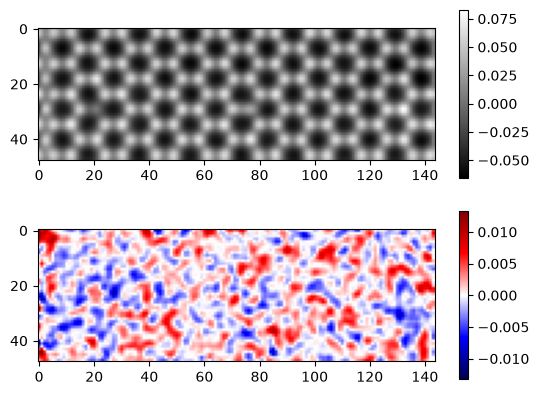

tv_channel_diff=0, channel_diff_sparcity=5
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

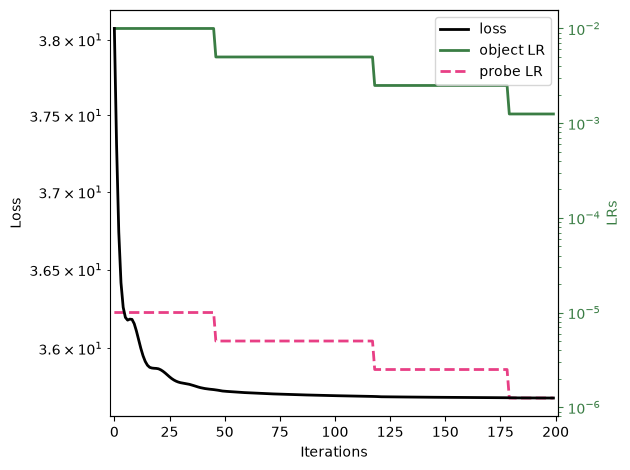

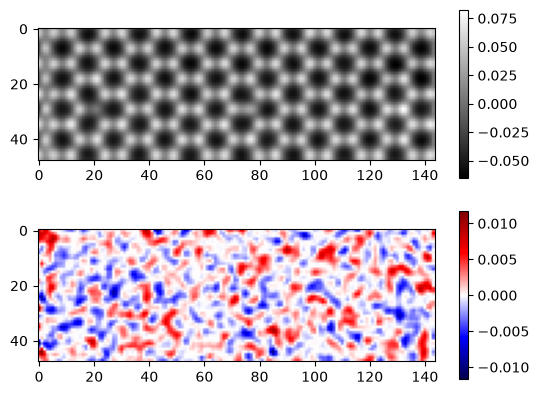

tv_channel_diff=0, channel_diff_sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

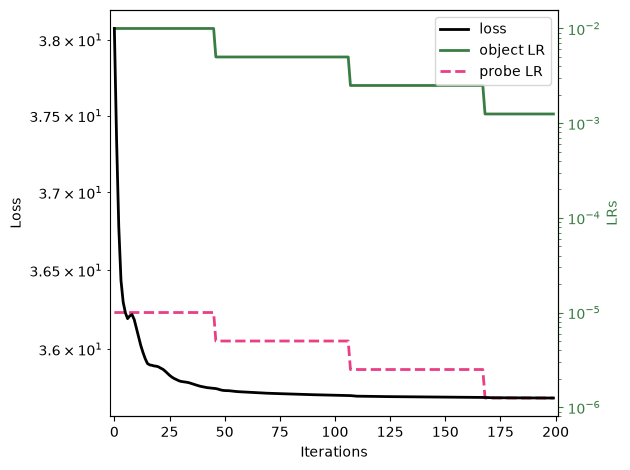

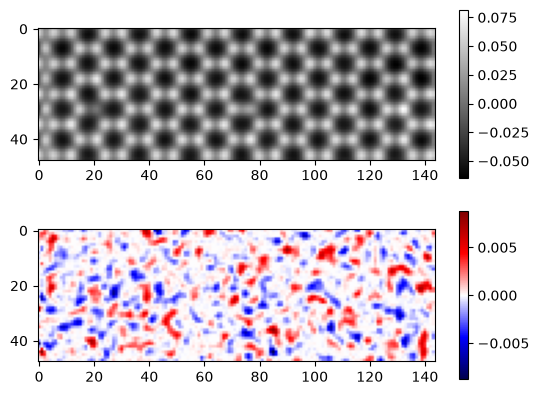

tv_channel_diff=1, channel_diff_sparcity=0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

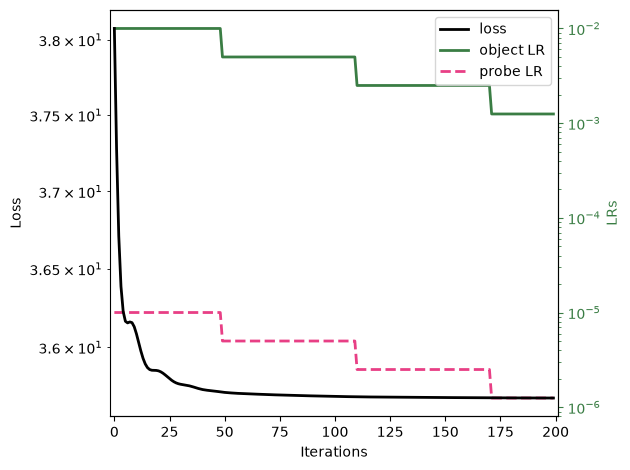

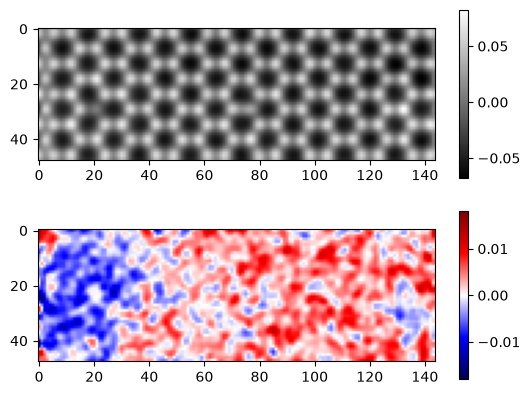

tv_channel_diff=1, channel_diff_sparcity=1
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

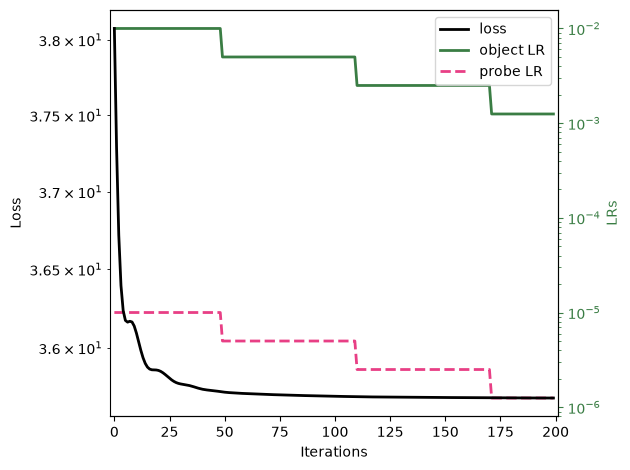

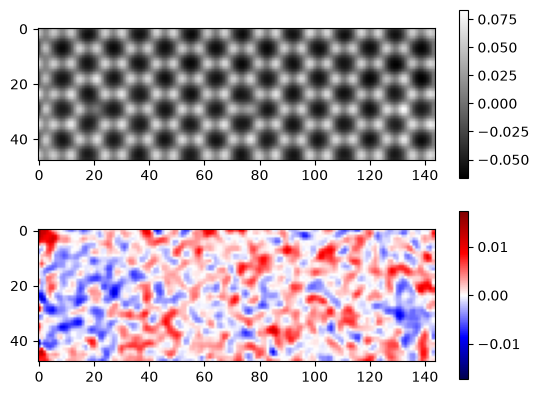

tv_channel_diff=1, channel_diff_sparcity=3
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

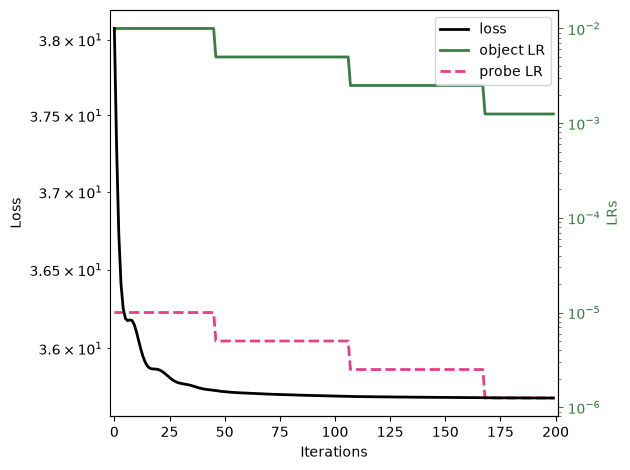

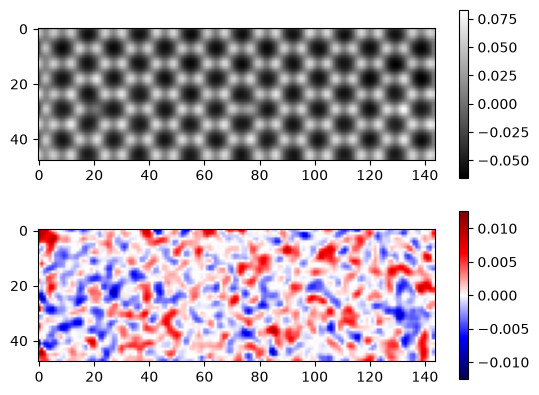

tv_channel_diff=1, channel_diff_sparcity=5
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

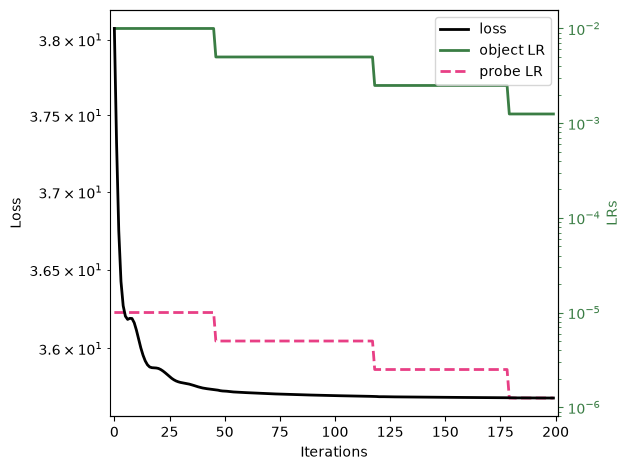

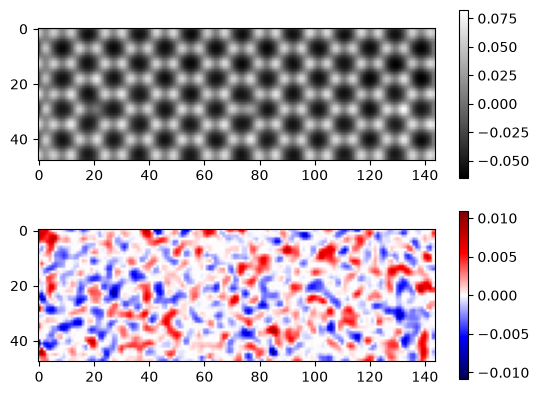

tv_channel_diff=1, channel_diff_sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

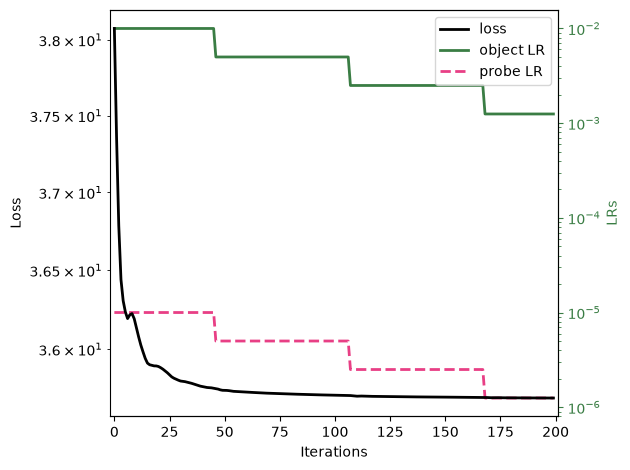

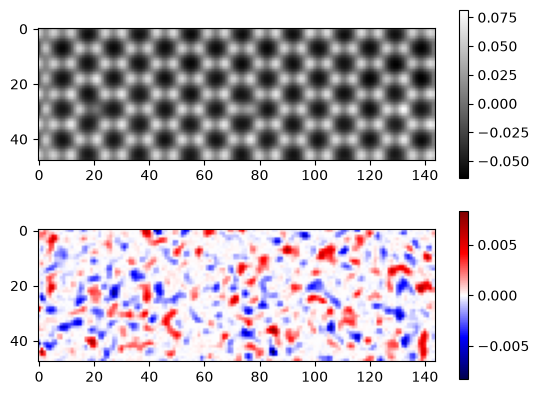

tv_channel_diff=5, channel_diff_sparcity=0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

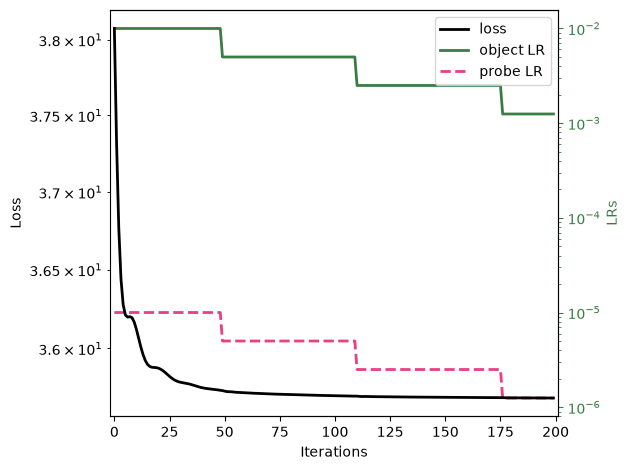

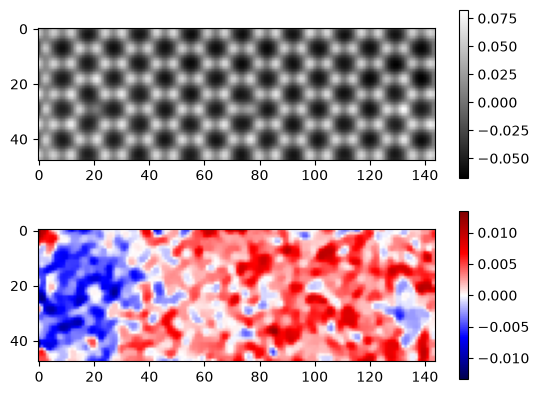

tv_channel_diff=5, channel_diff_sparcity=1
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

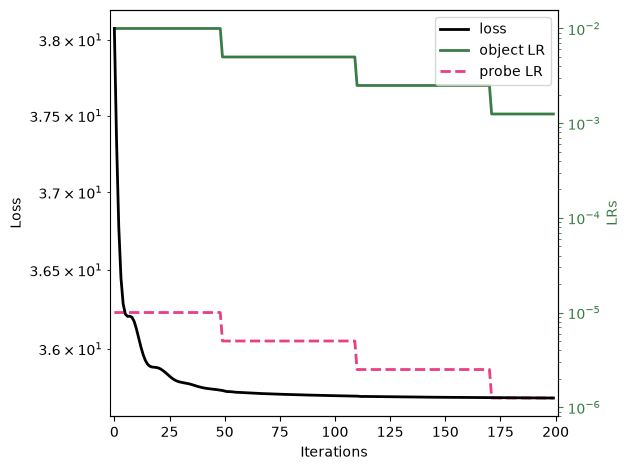

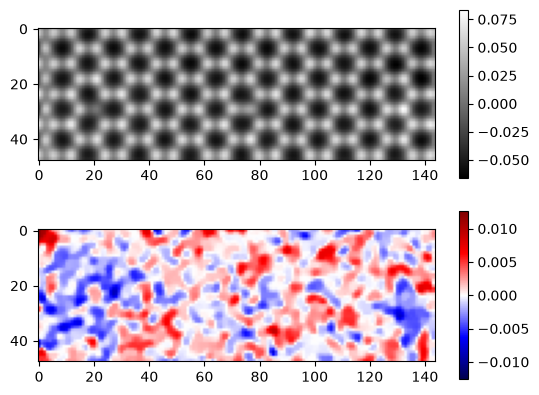

tv_channel_diff=5, channel_diff_sparcity=3
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

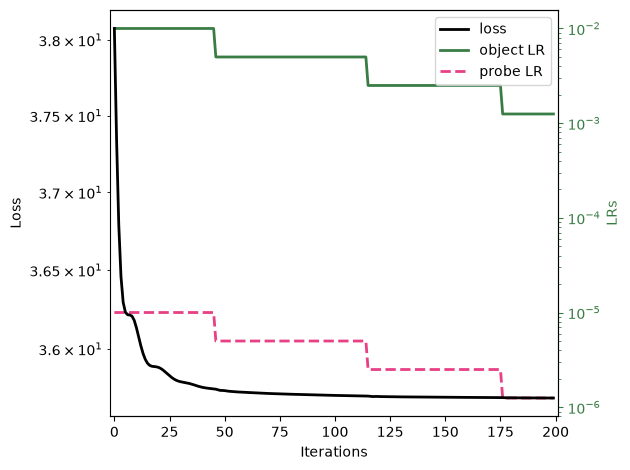

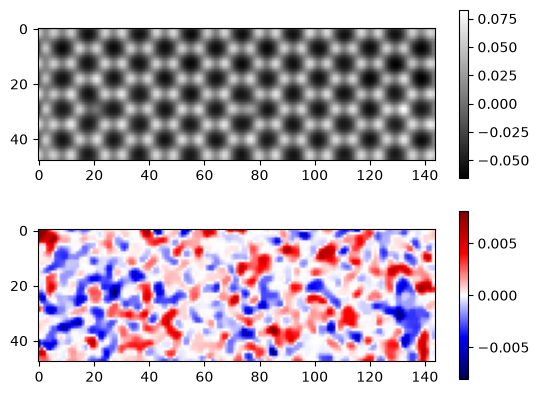

tv_channel_diff=5, channel_diff_sparcity=5
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

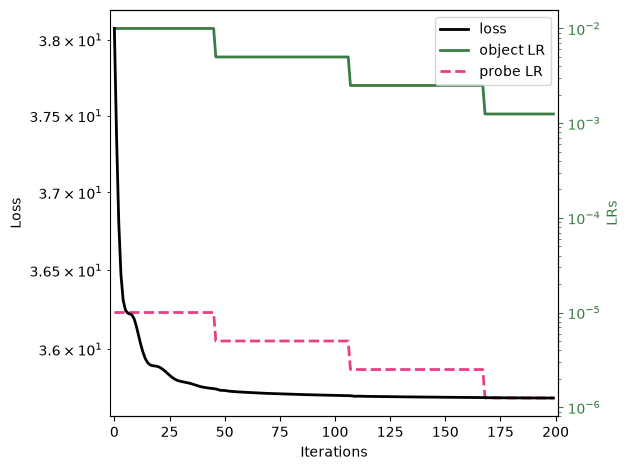

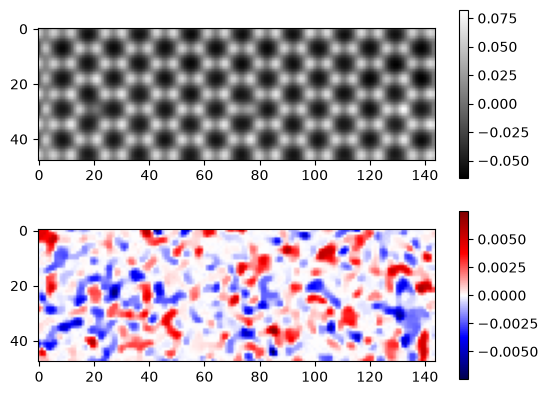

tv_channel_diff=5, channel_diff_sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

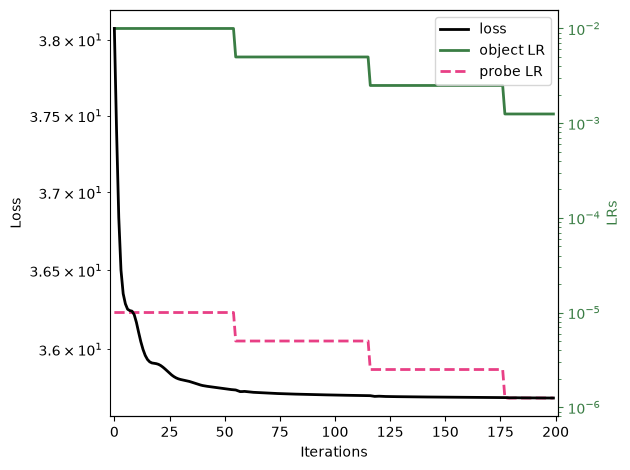

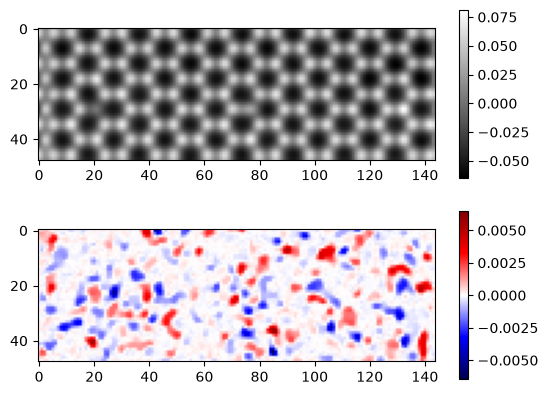

tv_channel_diff=10, channel_diff_sparcity=0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

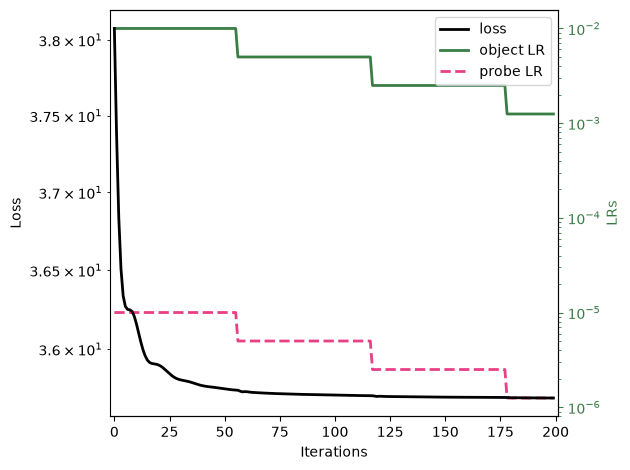

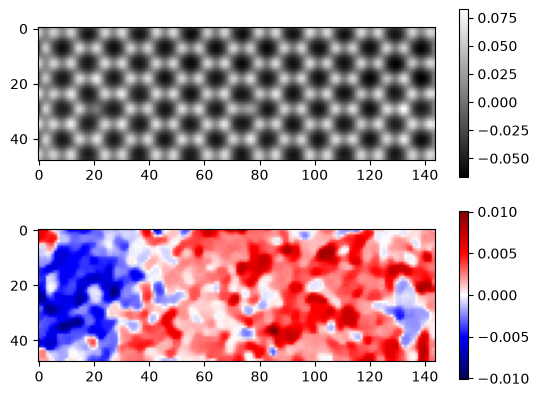

tv_channel_diff=10, channel_diff_sparcity=1
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

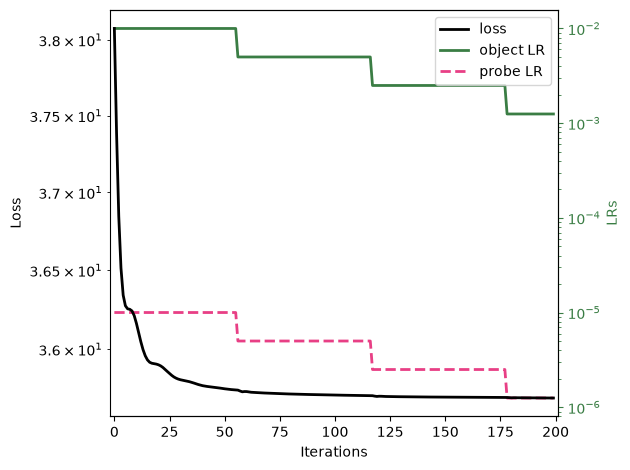

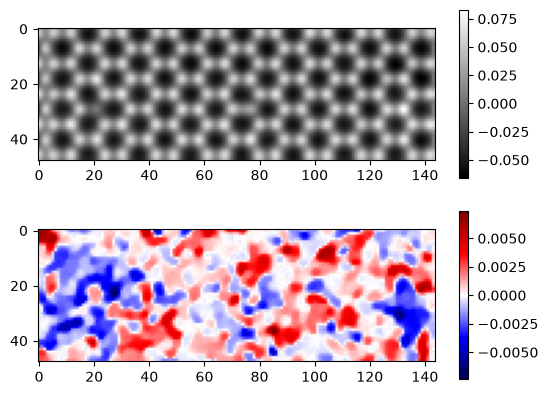

tv_channel_diff=10, channel_diff_sparcity=3
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

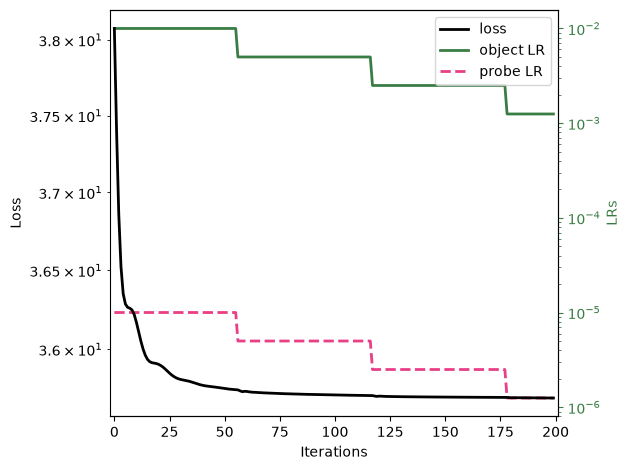

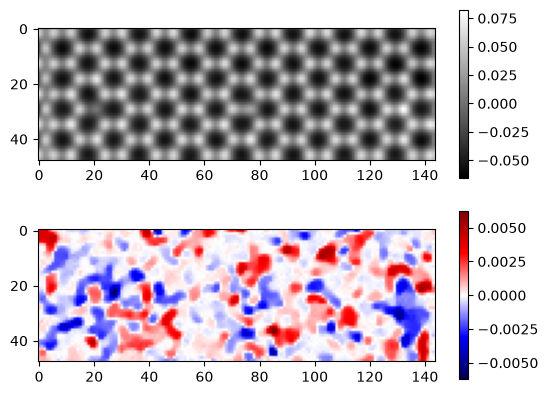

tv_channel_diff=10, channel_diff_sparcity=5
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

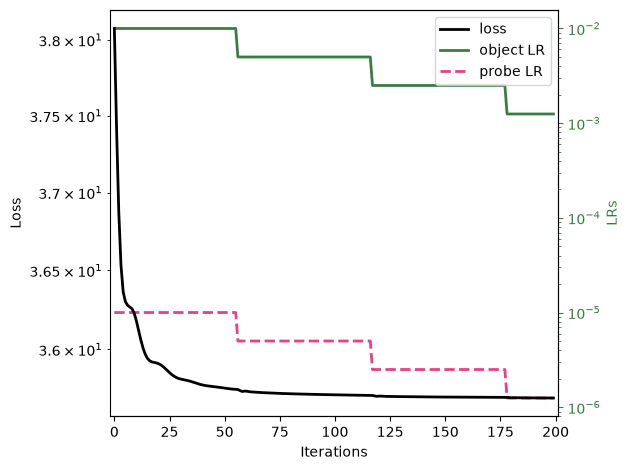

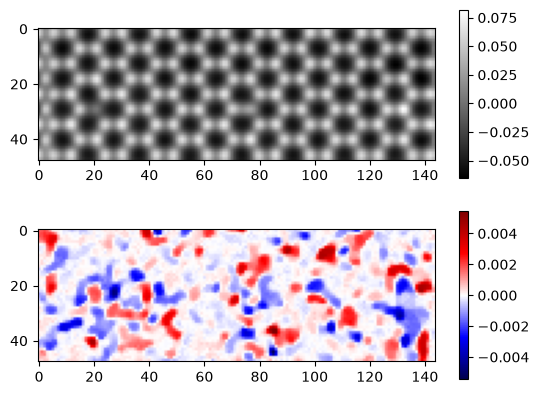

tv_channel_diff=10, channel_diff_sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

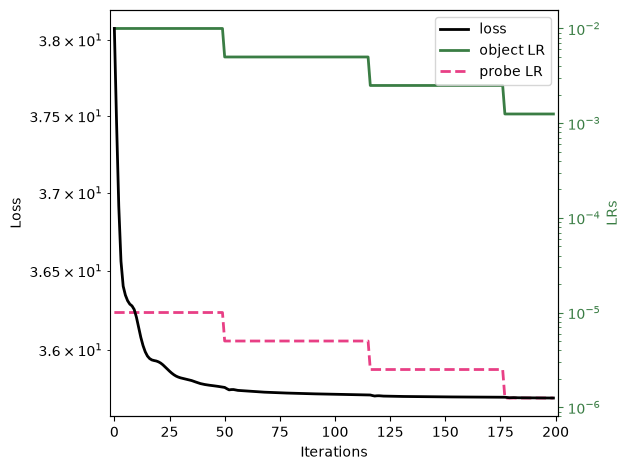

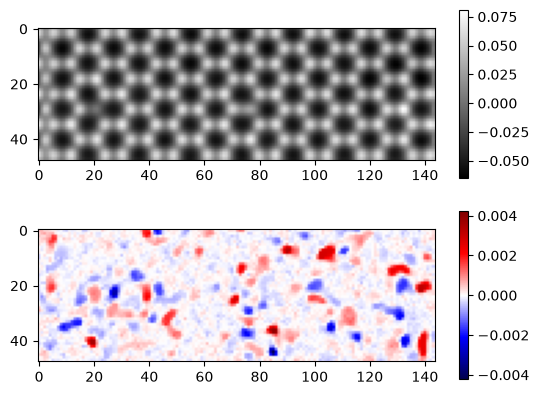

tv_channel_diff=20, channel_diff_sparcity=0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

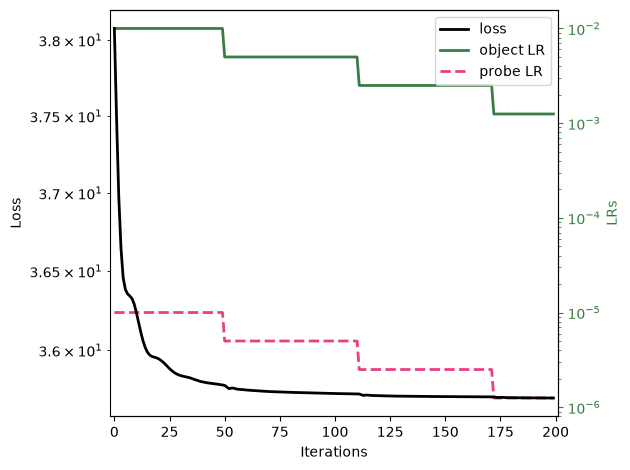

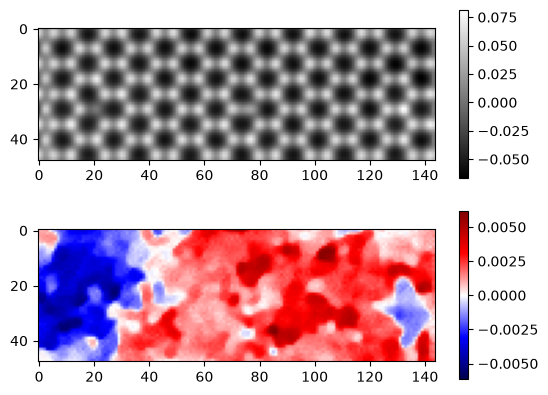

tv_channel_diff=20, channel_diff_sparcity=1
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

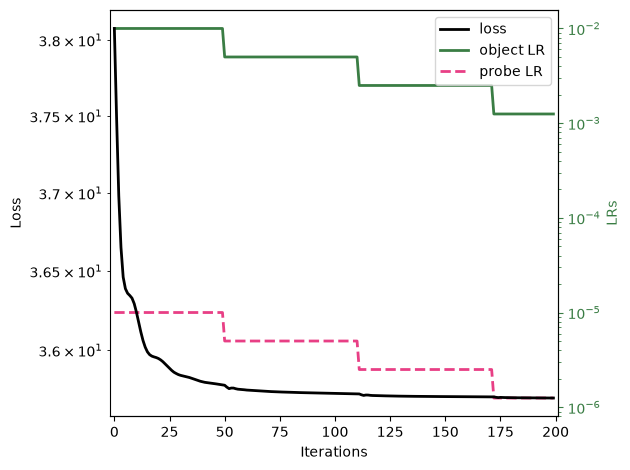

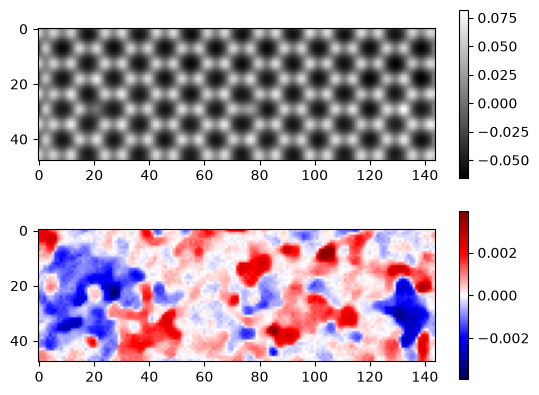

tv_channel_diff=20, channel_diff_sparcity=3
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

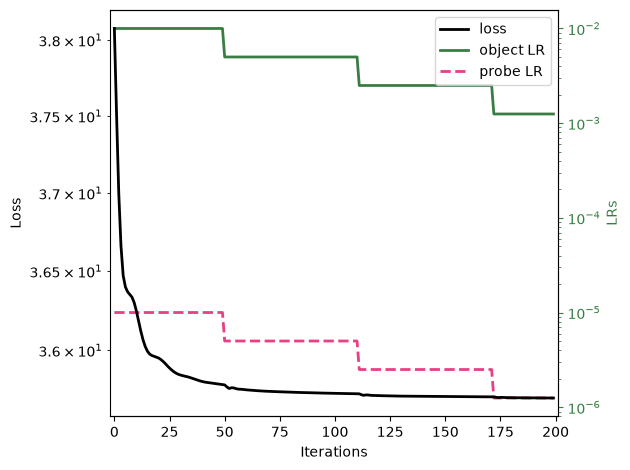

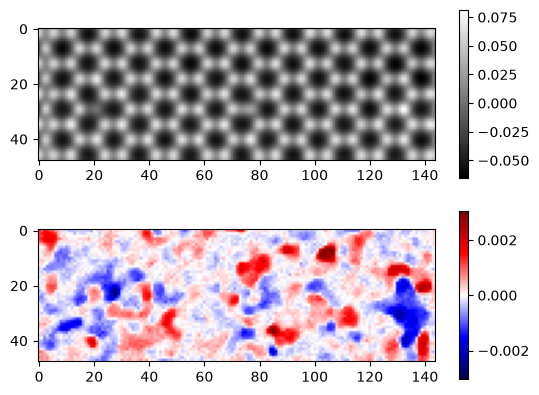

tv_channel_diff=20, channel_diff_sparcity=5
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

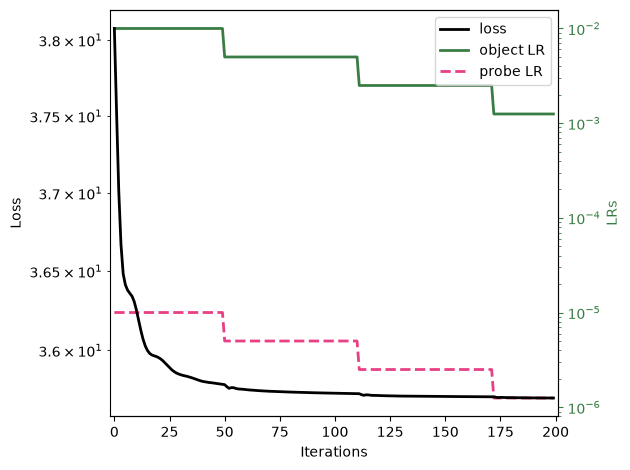

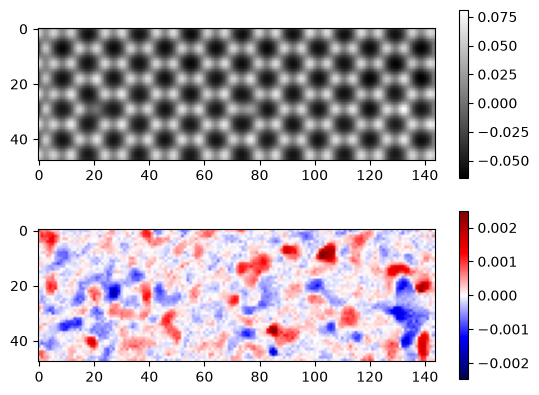

tv_channel_diff=20, channel_diff_sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/2465 [00:00<?, ?probe position/s]

  0%|          | 0/200 [00:00<?, ?it/s]

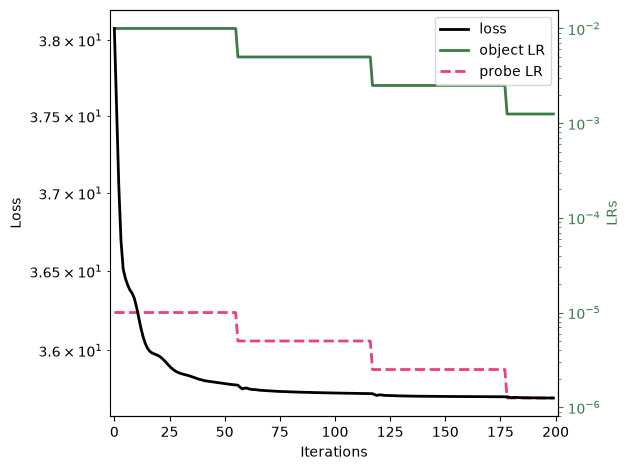

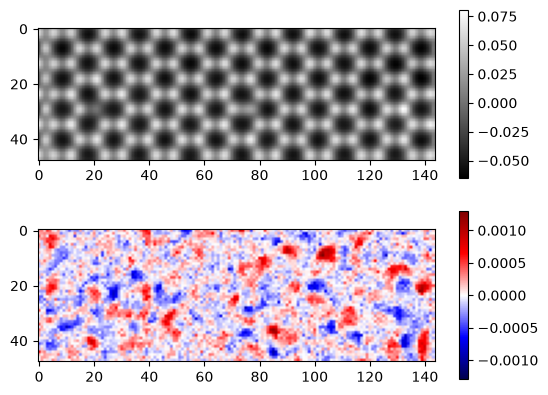

In [58]:
for tv_channel_diff in (0, 1, 5, 10, 20):
    for channel_diff_sparcity in (0, 1, 3, 5, 10):
        print(f"tv_channel_diff={tv_channel_diff}, channel_diff_sparcity={channel_diff_sparcity}")
        recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
            dcube=scan,
            scan_mask=scan_mask,
            num_iters=200,
            tv_channel_diff=tv_channel_diff,
            tv_weight=0.0,
            channel_diff_sparcity=channel_diff_sparcity,
            obj_lr=1e-2,
            return_extra=True,
            batch_size=2**12,
            obj_padding=64
        )